In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import plotly.express as px
import warnings
import certifi

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df = pd.read_csv(r"TaxiNYC.csv")
df

,Unnamed: 0,timestamp,value
0,0,2014-07-01 00:00:00,10844
1,1,2014-07-01 00:30:00,8127
2,2,2014-07-01 01:00:00,6210
3,3,2014-07-01 01:30:00,4656
4,4,2014-07-01 02:00:00,3820
...,...,...,...
10315,10315,2015-01-31 21:30:00,24670
10316,10316,2015-01-31 22:00:00,25721
10317,10317,2015-01-31 22:30:00,27309
10318,10318,2015-01-31 23:00:00,26591


In [3]:
df = df.rename(columns={
    "Unnamed: 0":"Unique_ID",
    "value": "passengers"
})

In [4]:
df.columns

Index(['Unique_ID', 'timestamp', 'passengers'], dtype='object')

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unique_ID,10320.0,5159.50000,2979.271723,0.0,2579.75,5159.5,7739.25,10319.0
passengers,10320.0,15137.56938,6939.495808,8.0,10262.00,16778.0,19838.75,39197.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10320 entries, 0 to 10319
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unique_ID   10320 non-null  int64 
 1   timestamp   10320 non-null  object
 2   passengers  10320 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 242.0+ KB


In [9]:
df.drop("Unique_ID",axis=1,inplace=True)

In [10]:
df

,timestamp,passengers
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820
...,...,...
10315,2015-01-31 21:30:00,24670
10316,2015-01-31 22:00:00,25721
10317,2015-01-31 22:30:00,27309
10318,2015-01-31 23:00:00,26591


In [14]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')
df

,timestamp,passengers
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820
...,...,...
10315,2015-01-31 21:30:00,24670
10316,2015-01-31 22:00:00,25721
10317,2015-01-31 22:30:00,27309
10318,2015-01-31 23:00:00,26591


In [15]:
df['difff'] = df['timestamp'].diff()
df['difff'].value_counts()

difff
0 days 00:30:00    10319
Name: count, dtype: int64

In [16]:
df

,timestamp,passengers,difff
0,2014-07-01 00:00:00,10844,NaT
1,2014-07-01 00:30:00,8127,0 days 00:30:00
2,2014-07-01 01:00:00,6210,0 days 00:30:00
3,2014-07-01 01:30:00,4656,0 days 00:30:00
4,2014-07-01 02:00:00,3820,0 days 00:30:00
...,...,...,...
10315,2015-01-31 21:30:00,24670,0 days 00:30:00
10316,2015-01-31 22:00:00,25721,0 days 00:30:00
10317,2015-01-31 22:30:00,27309,0 days 00:30:00
10318,2015-01-31 23:00:00,26591,0 days 00:30:00


In [17]:
# Looking for Missing timestamps.
full_range = pd.date_range(
    start=df['timestamp'].min(),
    end=df['timestamp'].max(),
    freq='30T'
)
missing = full_range.difference(df['timestamp'])
len(missing)

0

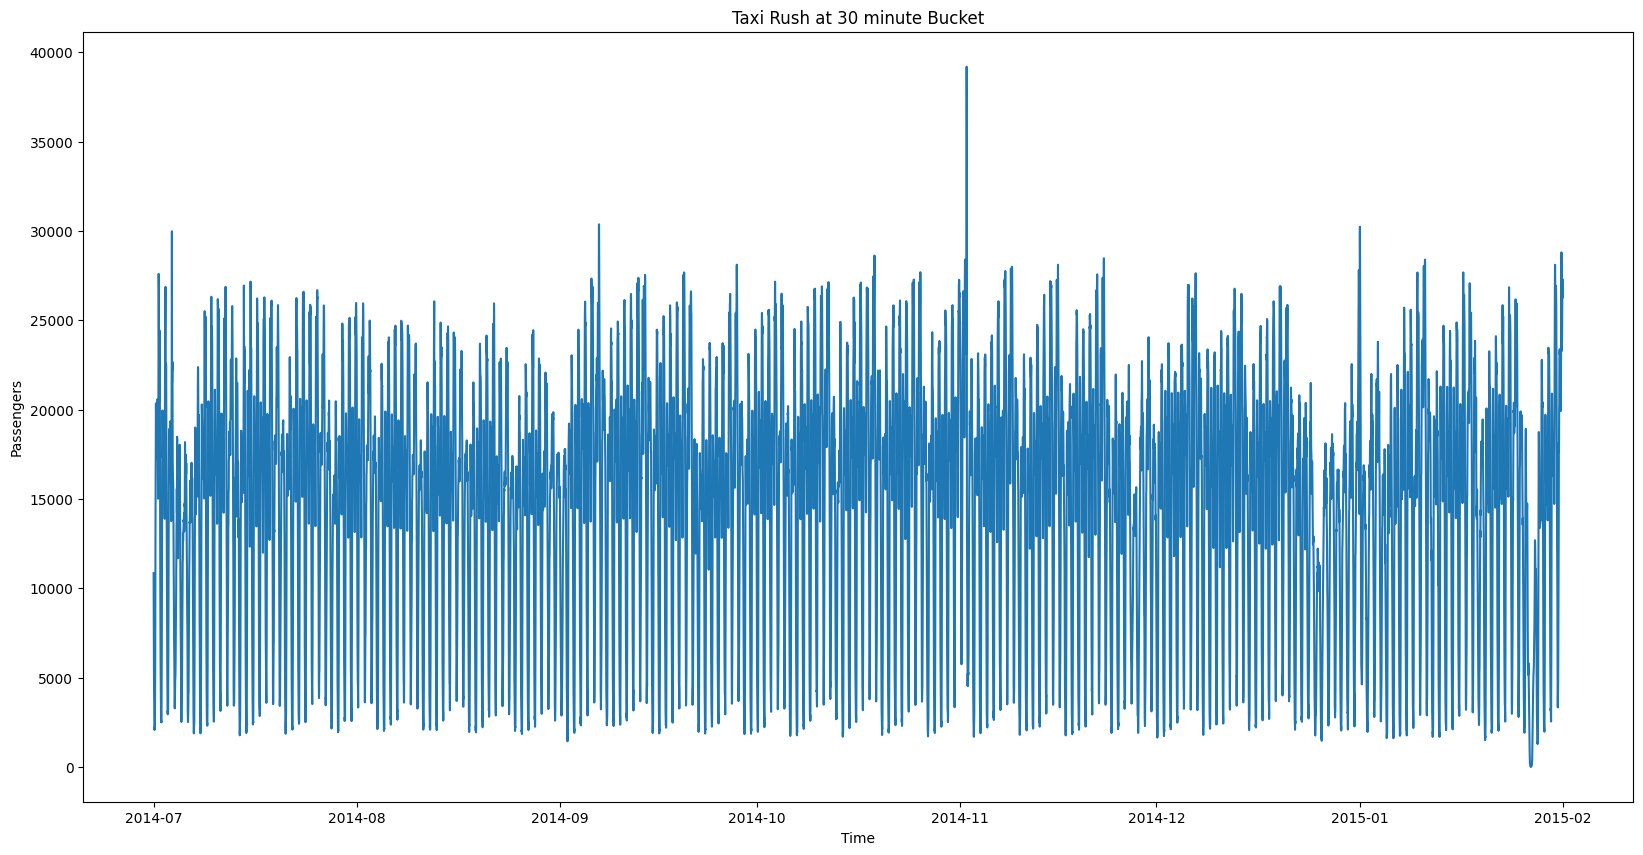

In [25]:
plt.figure(figsize=(20,10))
plt.plot(df['timestamp'], df['passengers'])
plt.title("Taxi Rush at 30 minute Bucket")
plt.ylabel("Passengers")
plt.xlabel("Time")
plt.show();